In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
%pwd

'/home/gabriel/codes/MC859/mc859-projeto-grafos/handle-graph/notebooks'

In [16]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Ajuste o caminho abaixo para a pasta do seu projeto no Drive
    BASE_DIR = '/content/drive/MyDrive/MC859/datasets'
except ImportError:
    # Fallback caso rode localmente
    BASE_DIR = '/home/gabriel/codes/MC859/mc859-projeto-grafos/dataset/final-graphs'

In [17]:


# Configuração visual profissional
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# =====================================================================
# 1. CARREGAR AMBAS AS INSTÂNCIAS
# =====================================================================
# Substitua pelos caminhos reais dos seus arquivos gerados pelo build_graph.py
FILE_IMED = f"{BASE_DIR}/final-graph-imed/edges.json"   # ou o nome do arquivo da 1ª instância
FILE_PAST3 = f"{BASE_DIR}/final-graph-past3/edges.json" # ou o nome do arquivo da 2ª instância

print("Carregando dados de G_imed...")
with open(FILE_IMED, "r", encoding="utf-8") as f:
    df_imed = pd.DataFrame(json.load(f))
df_imed['instancia'] = r'$G_{imed}$'

print("Carregando dados de G_past3...")
with open(FILE_PAST3, "r", encoding="utf-8") as f:
    df_past3 = pd.DataFrame(json.load(f))
df_past3['instancia'] = r'$G_{past3}$'

# Combinar os DataFrames para facilitar a plotagem comparativa
df_total = pd.concat([df_imed, df_past3], ignore_index=True)

# =====================================================================
# 2. CALCULAR E SALVAR RELATÓRIO DE ESTATÍSTICAS (TXT)
# =====================================================================
def obter_stats(df):
    w = df['weight'].to_numpy()
    pos = np.sum(w > 0.05)
    neg = np.sum(w < -0.05)
    neu = len(w) - pos - neg
    return {
        "Total Arestas": len(w),
        "Mínimo": np.min(w),
        "Máximo": np.max(w),
        "Média": np.mean(w),
        "Mediana": np.median(w),
        "Desvio Padrão": np.std(w),
        "Saudáveis (%)": (pos / len(w)) * 100,
        "Tóxicas (%)": (neg / len(w)) * 100,
        "Neutras (%)": (neu / len(w)) * 100
    }

stats_imed = obter_stats(df_imed)
stats_past3 = obter_stats(df_past3)

# Montar DataFrame do relatório para salvar
df_report = pd.DataFrame([stats_imed, stats_past3], index=["G_imed", "G_past3"]).T

# Salvar em arquivo de texto formatado
relatorio_path = "estatisticas_pesos_comparativo.txt"
with open(relatorio_path, "w", encoding="utf-8") as f:
    f.write("==================================================\n")
    f.write("      RELATÓRIO COMPARATIVO DE PESOS DAS REDES    \n")
    f.write("==================================================\n\n")
    f.write(df_report.to_string())
    f.write("\n\n==================================================")

print(f"✓ Estatísticas consolidadas salvas em '{relatorio_path}'")

# =====================================================================
# 3. GRÁFICOS COMPARATIVOS
# =====================================================================

# Gráfico 1: Curva de Densidade Sobreposta (KDE Plot)
# Excelente para ver para onde o "clima" da rede se deslocou com a mudança de modelagem
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_total, x='weight', hue='instancia', fill=True, common_norm=False, palette='Set1', alpha=0.4, linewidth=2)
plt.title("Comparação da Distribuição de Pesos: $G_{imed}$ vs $G_{past3}$", fontsize=13, pad=15)
plt.xlabel("Peso das Arestas (Valência) [-1, 1]")
plt.ylabel("Densidade de Ocorrência")
plt.xlim(-1.1, 1.1)
plt.tight_layout()
plt.savefig("comparativo_densidade_pesos.png", dpi=300)
plt.show()

# Gráfico 2: Gráfico de Barras Empilhadas (Balanço de Clima da Rede)
# Ótimo para mostrar de forma gerencial o percentual de toxicidade de cada uma
categorias = ["Saudáveis", "Tóxicas", "Neutras"]
dados_barras = {
    "Instância": [r"$G_{imed}$", r"$G_{imed}$", r"$G_{imed}$", r"$G_{past3}$", r"$G_{past3}$", r"$G_{past3}$"],
    "Tipo": ["Saudáveis", "Tóxicas", "Neutras", "Saudáveis", "Tóxicas", "Neutras"],
    "Percentual": [stats_imed["Saudáveis (%)"], stats_imed["Tóxicas (%)"], stats_imed["Neutras (%)"],
                   stats_past3["Saudáveis (%)"], stats_past3["Tóxicas (%)"], stats_past3["Neutras (%)"]]
}
df_barras = pd.DataFrame(dados_barras)

# Pivotar para criar o gráfico empilhado de proporção
df_pivot = df_barras.pivot(index='Instância', columns='Tipo', values='Percentual')
df_pivot = df_pivot[['Saudáveis', 'Neutras', 'Tóxicas']] # Reordenar esteticamente

ax = df_pivot.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#4caf50', '#9e9e9e', '#f44336'], width=0.4)
plt.title("Proporção Comparativa do Clima nas Duas Redes", fontsize=13, pad=15)
plt.xlabel("Instância do Grafo")
plt.ylabel("Percentual das Arestas (%)")
plt.xticks(rotation=0)
plt.ylim(0, 110)

# Adicionar os rótulos de texto dentro das barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Só coloca se a barra for visível
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Classificação")
plt.tight_layout()
plt.savefig("comparativo_proporcao_clima.png", dpi=300)
plt.show()

print("\n✓ Gráficos comparativos salvos como PNG!")

Carregando dados de G_imed...
Carregando dados de G_past3...


: 

Carregando arestas...
Total de 739,875 arestas carregadas.

       NOVAS ESTATÍSTICAS GERAIS DOS PESOS        
Peso Mínimo (Maior Toxicidade):   -1.0000
Peso Máximo (Maior Saudabilidade): 0.5726
Peso Médio das Interações:         0.1208
Mediana dos Pesos:                 0.1413
Desvio Padrão dos Pesos:           0.1931
--------------------------------------------------
Conexões Saudáveis (Peso > 0.05):  499,726 (67.54%)
Conexões Tóxicas (Peso < -0.05):   120,246 (16.25%)
Conexões Neutras:                  119,903 (16.21%)

Estatísticas detalhadas por tipo de interação:
          count      mean       std   min     max
type                                             
comment  629289  0.106293  0.191047 -1.00  0.5726
review   110586  0.203150  0.183692 -0.79  0.5704


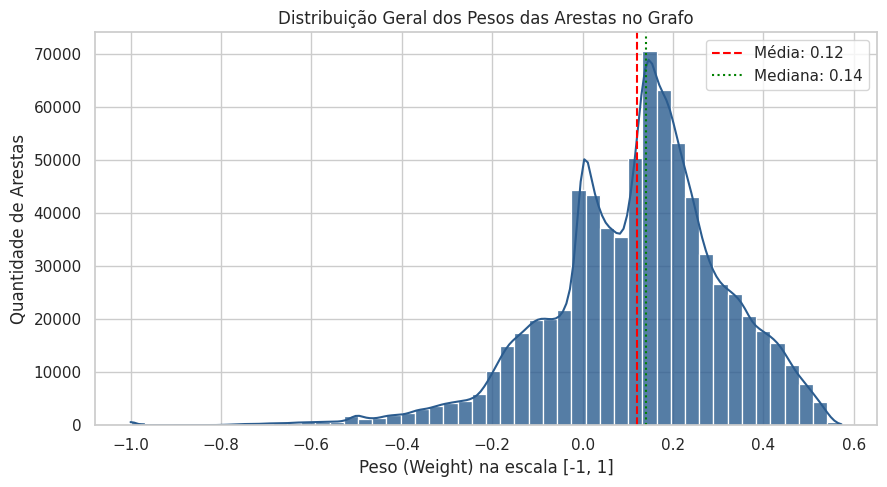

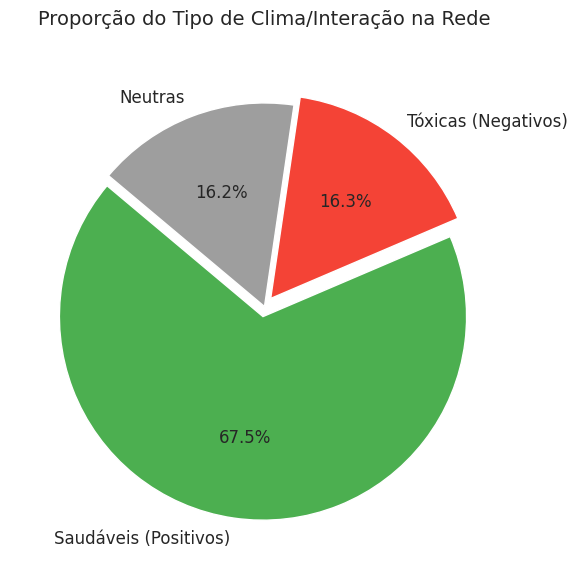

/tmp/ipykernel_11711/3527964468.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='weight', data=df, palette='Set2', width=0.5)


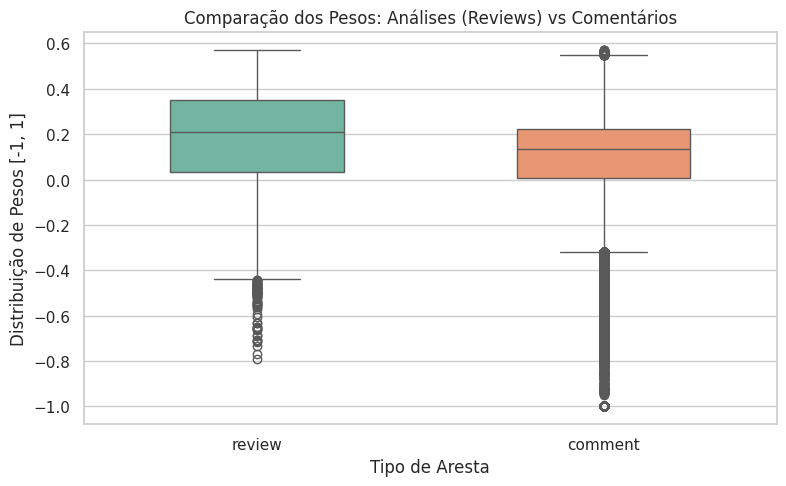


Gráficos salvos com sucesso como arquivos PNG no seu Colab! ✓


In [ ]:
# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# 1. CARREGAR OS DADOS
# Substitua pelo caminho correto do seu arquivo 'edges.json' ou 'review_edges.json'
print("Carregando arestas...")
with open(FILE_IMED, "r", encoding="utf-8") as f:
    edges = json.load(f)

# Converter para DataFrame para facilitar a análise estatística
df = pd.DataFrame(edges)
print(f"Total de {len(df):,} arestas carregadas.\n")

# 2. EXTRAIR ESTATÍSTICAS INÉDITAS DE PESOS
weights = df['weight'].to_numpy()

peso_min = np.min(weights)
peso_max = np.max(weights)
peso_medio = np.mean(weights)
peso_mediana = np.median(weights)
desvio_padrao = np.std(weights)

# Separando interações por valência (Positiva, Negativa, Neutra)
positivas = df[df['weight'] > 0.05]
negativas = df[df['weight'] < -0.05]
neutras = df[(df['weight'] >= -0.05) & (df['weight'] <= 0.05)]

pct_positivas = (len(positivas) / len(df)) * 100
pct_negativas = (len(negativas) / len(df)) * 100
pct_neutras = (len(neutras) / len(df)) * 100

# Estatísticas por tipo de interação (Review vs Comment)
stats_por_tipo = df.groupby('type')['weight'].agg(['count', 'mean', 'std', 'min', 'max'])

# Exibir relatório de estatísticas no console
print("==================================================")
print("       NOVAS ESTATÍSTICAS GERAIS DOS PESOS        ")
print("==================================================")
print(f"Peso Mínimo (Maior Toxicidade):   {peso_min:.4f}")
print(f"Peso Máximo (Maior Saudabilidade): {peso_max:.4f}")
print(f"Peso Médio das Interações:         {peso_medio:.4f}")
print(f"Mediana dos Pesos:                 {peso_mediana:.4f}")
print(f"Desvio Padrão dos Pesos:           {desvio_padrao:.4f}")
print("--------------------------------------------------")
print(f"Conexões Saudáveis (Peso > 0.05):  {len(positivas):,} ({pct_positivas:.2f}%)")
print(f"Conexões Tóxicas (Peso < -0.05):   {len(negativas):,} ({pct_negativas:.2f}%)")
print(f"Conexões Neutras:                  {len(neutras):,} ({pct_neutras:.2f}%)")
print("==================================================")
print("\nEstatísticas detalhadas por tipo de interação:")
print(stats_por_tipo.to_string())


# 3. GERAÇÃO DOS GRÁFICOS PARA O RELATÓRIO

# Gráfico 1: Histograma de Distribuição dos Pesos
plt.figure(figsize=(9, 5))
sns.histplot(df['weight'], bins=50, kde=True, color='#2b5c8f', alpha=0.8)
plt.axvline(peso_medio, color='red', linestyle='--', linewidth=1.5, label=f'Média: {peso_medio:.2f}')
plt.axvline(peso_mediana, color='green', linestyle=':', linewidth=1.5, label=f'Mediana: {peso_mediana:.2f}')
plt.title("Distribuição Geral dos Pesos das Arestas no Grafo")
plt.xlabel("Peso (Weight) na escala [-1, 1]")
plt.ylabel("Quantidade de Arestas")
plt.legend()
plt.tight_layout()
plt.savefig("distribuicao_pesos.png", dpi=300)
plt.show()

# Gráfico 2: Gráfico de Pizza (Balanço da Rede)
plt.figure(figsize=(6, 6))
labels = ['Saudáveis (Positivos)', 'Tóxicas (Negativos)', 'Neutras']
sizes = [pct_positivas, pct_negativas, pct_neutras]
colors = ['#4caf50', '#f44336', '#9e9e9e']
explode = (0.05, 0.05, 0)  # Destacar os polos

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Pizza (Lado Esquerdo - axes[0]) ---
# No matplotlib, chamamos o método direto no eixo específico (.pie)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=False, startangle=140, textprops={'fontsize': 12})
axes[0].set_title("Proporção do Tipo de Clima/Interação na Rede", fontsize=14, pad=20)

# --- Gráfico 2: Boxplot (Lado Direito - axes[1]) ---
# No seaborn, passamos o eixo correto usando o parâmetro ax=axes[1]
sns.boxplot(x='type', y='weight', data=df, palette='Set2', width=0.5, ax=axes[1])
axes[1].set_title("Comparação dos Pesos: Análises (Reviews) vs Comentários", fontsize=14, pad=20)
axes[1].set_xlabel("Tipo de Aresta", fontsize=12)
axes[1].set_ylabel("Distribuição de Pesos [-1, 1]", fontsize=12)

# --- Ajustes Finais e Salvamento ---
plt.tight_layout()  # Ajusta o espaçamento para não sobrepor textos
plt.savefig("analise_combinada_rede.png", dpi=300)
plt.show()

print("\nGráficos salvos com sucesso como arquivos PNG no seu Colab! ✓")